# Fraudulent Transaction Detection Using DBSCAN

## DBSCAN-Based Unsupervised Anomaly Detection

This notebook builds an unsupervised fraud/anomaly detection pipeline using **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**.

### Workflow
1. Load and validate the transaction dataset
2. Prepare features for unsupervised learning
3. Engineer useful behavioral/time features
4. Encode categorical variables and scale numeric variables
5. Select DBSCAN parameters using a k-distance graph
6. Detect anomalies using DBSCAN noise points (`-1`)
7. Evaluate anomalies against the known fraud labels
8. Visualize clusters and anomalies
9. Compare `eps` parameter choices
10. Build the final DBSCAN model and suspicious transaction report
11. Perform research-grade validation and anomaly interpretation
12. Document limitations and responsible interpretation
13. Export the final results
14. Summarize the complete project in the conclusion

> **Important:** `Fraud_Label` is NOT used as an input to DBSCAN. It is used only for post-hoc evaluation.

## 1. Import Libraries & Load Dataset

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Upload the CSV when running in Google Colab
from google.colab import files

uploaded = files.upload()
csv_file = next(name for name in uploaded if name.lower().endswith(".csv"))
df = pd.read_csv(csv_file)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Saving fraud_transaction_dataset_1000_fixed.csv to fraud_transaction_dataset_1000_fixed (1).csv
Dataset loaded successfully.
Shape: (1000, 20)


,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Hour,Transaction_Frequency_24H,Location,Location_Distance_KM,Device_Change,International_Transaction,Login_Attempts,Account_Age_Days,Previous_Transaction_Avg,Amount_Deviation,Merchant_Risk_Score,Transaction_Duration_Sec,Account_Balance,Transaction_Type,Channel,Fraud_Label,Amount_to_Balance_Ratio
0,TX00522,C1168,633.32,18,5,Warangal,15.73,0,0,2,290,602.82,0.051,0.446,53.43,8965.93,Online,Web,0,0.0706
1,TX00738,C1190,883.31,11,6,Warangal,13.05,0,0,0,615,1119.94,0.211,0.299,22.95,12562.14,Online,POS,0,0.0703
2,TX00741,C1217,1333.50,12,4,Visakhapatnam,1.06,0,0,0,741,1265.47,0.054,0.135,49.53,5778.50,Online,Mobile,0,0.2308
3,TX00661,C1165,553.36,17,5,Guntur,10.53,0,0,0,452,493.15,0.122,0.186,43.17,7442.51,POS,Mobile,0,0.0744
4,TX00412,C1031,718.22,10,4,Warangal,6.98,0,0,0,770,763.62,0.059,0.346,28.99,2989.66,POS,Mobile,0,0.2402


## 2. Data Inspection & Validation

In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nTotal Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (1000, 20)

Column Names:
['Transaction_ID', 'Customer_ID', 'Transaction_Amount', 'Transaction_Hour', 'Transaction_Frequency_24H', 'Location', 'Location_Distance_KM', 'Device_Change', 'International_Transaction', 'Login_Attempts', 'Account_Age_Days', 'Previous_Transaction_Avg', 'Amount_Deviation', 'Merchant_Risk_Score', 'Transaction_Duration_Sec', 'Account_Balance', 'Transaction_Type', 'Channel', 'Fraud_Label', 'Amount_to_Balance_Ratio']

Data Types:
Transaction_ID                object
Customer_ID                   object
Transaction_Amount           float64
Transaction_Hour               int64
Transaction_Frequency_24H      int64
Location                      object
Location_Distance_KM         float64
Device_Change                  int64
International_Transaction      int64
Login_Attempts                 int64
Account_Age_Days               int64
Previous_Transaction_Avg     float64
Amount_Deviation             float64
Merchant_Risk_Score          float64
Transaction_

Fraud Label Distribution:
Fraud_Label
0    900
1    100
Name: count, dtype: int64

Fraud Percentage:
Fraud_Label
0    90.0
1    10.0
Name: proportion, dtype: float64


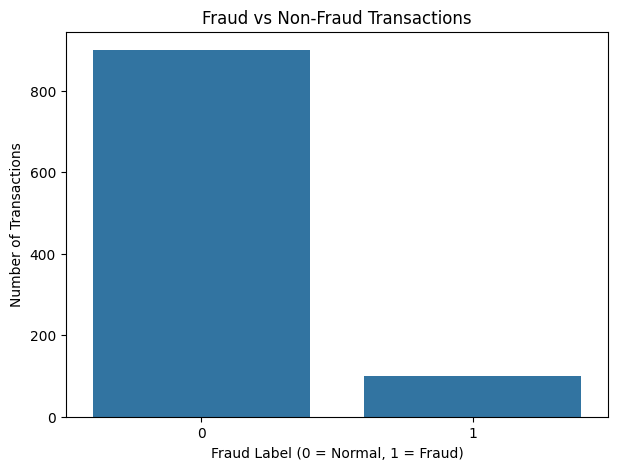

In [ ]:
print("Fraud Label Distribution:")
print(df["Fraud_Label"].value_counts().sort_index())

print("\nFraud Percentage:")
print((df["Fraud_Label"].value_counts(normalize=True).sort_index() * 100).round(2))

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Fraud_Label")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Label (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

## 3. Prepare Data for Unsupervised Learning

`Fraud_Label` is saved separately for evaluation only. Identifiers are removed because they do not represent transaction behavior.

In [ ]:
y_true = df["Fraud_Label"].copy()

X = df.drop(
    columns=["Fraud_Label", "Transaction_ID", "Customer_ID"]
).copy()

print("Fraud_Label excluded from DBSCAN input.")
print("Identifiers excluded from DBSCAN input.")
print("\nFeatures used for DBSCAN:")
print(X.columns.tolist())

Fraud_Label excluded from DBSCAN input.
Identifiers excluded from DBSCAN input.

Features used for DBSCAN:
['Transaction_Amount', 'Transaction_Hour', 'Transaction_Frequency_24H', 'Location', 'Location_Distance_KM', 'Device_Change', 'International_Transaction', 'Login_Attempts', 'Account_Age_Days', 'Previous_Transaction_Avg', 'Amount_Deviation', 'Merchant_Risk_Score', 'Transaction_Duration_Sec', 'Account_Balance', 'Transaction_Type', 'Channel', 'Amount_to_Balance_Ratio']


## 4. Feature Engineering

Transaction hour is represented cyclically so that times near midnight remain close to each other. Selected highly skewed numeric variables are log-transformed before scaling.

In [ ]:
X["Hour_Sin"] = np.sin(2 * np.pi * X["Transaction_Hour"] / 24)
X["Hour_Cos"] = np.cos(2 * np.pi * X["Transaction_Hour"] / 24)
X.drop(columns=["Transaction_Hour"], inplace=True)

log_features = [
    "Transaction_Amount",
    "Location_Distance_KM",
    "Login_Attempts",
    "Account_Balance",
    "Amount_Deviation",
    "Previous_Transaction_Avg"
]

for col in log_features:
    X[col] = np.log1p(X[col])

print("Feature engineering completed.")
print("Current shape:", X.shape)

Feature engineering completed.
Current shape: (1000, 18)


## 5. Encode & Scale Features

DBSCAN is distance-based, so categorical variables are one-hot encoded and numeric variables are transformed using `RobustScaler`.

In [ ]:
categorical_features = ["Location", "Transaction_Type", "Channel"]

numerical_features = [
    "Transaction_Amount",
    "Transaction_Frequency_24H",
    "Location_Distance_KM",
    "Device_Change",
    "International_Transaction",
    "Login_Attempts",
    "Account_Age_Days",
    "Previous_Transaction_Avg",
    "Amount_Deviation",
    "Merchant_Risk_Score",
    "Transaction_Duration_Sec",
    "Account_Balance",
    "Amount_to_Balance_Ratio",
    "Hour_Sin",
    "Hour_Cos"
]

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("num", RobustScaler(), numerical_features),
    ("cat", encoder, categorical_features)
])

X_scaled = preprocessor.fit_transform(X)

print("Preprocessing completed.")
print("Rows:", X_scaled.shape[0])
print("Processed features:", X_scaled.shape[1])

Preprocessing completed.
Rows: 1000
Processed features: 32


## 6. Select DBSCAN Parameters with a K-Distance Graph

DBSCAN requires `eps` and `min_samples`.

We use the k-distance graph to identify a sensible neighborhood-radius range from the structure of the feature space. For this dataset, the elbow region is around **2.9**, so `eps = 2.9` is selected for the final model.

> **Important:** `Fraud_Label` is not used to choose `eps`. The fraud labels are used only later for post-hoc evaluation and sensitivity analysis.

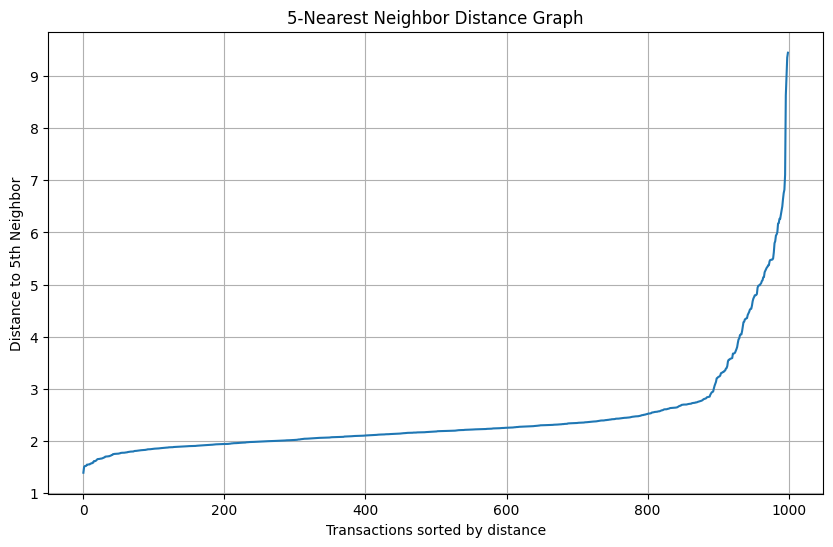

The elbow / sharp rise is inspected to guide eps selection.
For this dataset, the selected starting value is eps = 2.9.


In [ ]:
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)

distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title(f"{min_samples}-Nearest Neighbor Distance Graph")
plt.xlabel("Transactions sorted by distance")
plt.ylabel(f"Distance to {min_samples}th Neighbor")
plt.grid(True)
plt.show()

print("The elbow / sharp rise is inspected to guide eps selection.")
print("For this dataset, the selected starting value is eps = 2.9.")


## 7. Run DBSCAN & Inspect Clusters

DBSCAN assigns `-1` to observations considered noise. In this project, those noise observations are treated as candidate anomalies.

In [ ]:
# Selected from the k-distance graph
eps = 2.9

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples
)

cluster_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN completed.")
print("eps =", eps)
print("min_samples =", min_samples)


DBSCAN completed.
eps = 2.9
min_samples = 5


In [ ]:
unique_labels, counts = np.unique(cluster_labels, return_counts=True)
cluster_summary = pd.DataFrame({
    "Cluster": unique_labels,
    "Transactions": counts
}).sort_values("Cluster")

display(cluster_summary)

num_anomalies = int((cluster_labels == -1).sum())
print("Detected DBSCAN anomalies:", num_anomalies)
print("Anomaly percentage:", round(num_anomalies / len(cluster_labels) * 100, 2), "%")

,Cluster,Transactions
0,-1,104
1,0,896


Detected DBSCAN anomalies: 104
Anomaly percentage: 10.4 %


## 8. Create the Anomaly Results Table

In [ ]:
results_df = df.copy()
results_df["DBSCAN_Cluster"] = cluster_labels
results_df["DBSCAN_Anomaly"] = (results_df["DBSCAN_Cluster"] == -1).astype(int)

print("Results table created.")
display(results_df.head())

Results table created.


,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Hour,Transaction_Frequency_24H,Location,Location_Distance_KM,Device_Change,International_Transaction,Login_Attempts,...,Amount_Deviation,Merchant_Risk_Score,Transaction_Duration_Sec,Account_Balance,Transaction_Type,Channel,Fraud_Label,Amount_to_Balance_Ratio,DBSCAN_Cluster,DBSCAN_Anomaly
0,TX00522,C1168,633.32,18,5,Warangal,15.73,0,0,2,...,0.051,0.446,53.43,8965.93,Online,Web,0,0.0706,0,0
1,TX00738,C1190,883.31,11,6,Warangal,13.05,0,0,0,...,0.211,0.299,22.95,12562.14,Online,POS,0,0.0703,0,0
2,TX00741,C1217,1333.50,12,4,Visakhapatnam,1.06,0,0,0,...,0.054,0.135,49.53,5778.50,Online,Mobile,0,0.2308,0,0
3,TX00661,C1165,553.36,17,5,Guntur,10.53,0,0,0,...,0.122,0.186,43.17,7442.51,POS,Mobile,0,0.0744,0,0
4,TX00412,C1031,718.22,10,4,Warangal,6.98,0,0,0,...,0.059,0.346,28.99,2989.66,POS,Mobile,0,0.2402,0,0


## 9. Evaluate Anomalies Against Known Fraud Labels

The fraud labels are used only after DBSCAN has completed. This is a post-hoc evaluation of how well the unsupervised anomalies correspond to the known labels.

In [ ]:
y_pred = results_df["DBSCAN_Anomaly"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("DBSCAN Anomaly Detection Performance")
print("=" * 45)
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Normal", "Fraud"], zero_division=0))

DBSCAN Anomaly Detection Performance
Accuracy : 99.60%
Precision: 96.15%
Recall   : 100.00%
F1-Score : 98.04%

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       900
       Fraud       0.96      1.00      0.98       100

    accuracy                           1.00      1000
   macro avg       0.98      1.00      0.99      1000
weighted avg       1.00      1.00      1.00      1000



## 10. Confusion Matrix & PCA Visualization

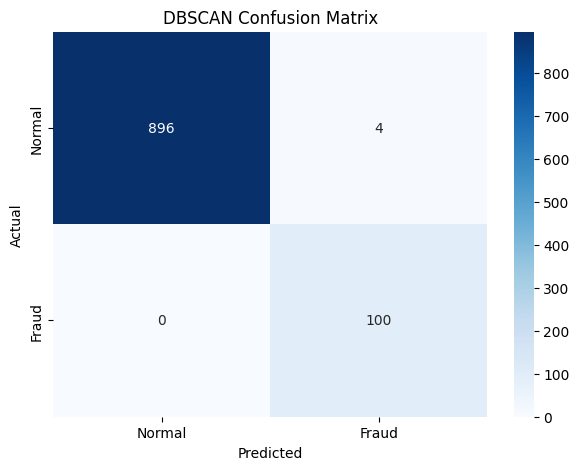

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Fraud"],
            yticklabels=["Normal", "Fraud"])
plt.title("DBSCAN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

PCA explained variance: 94.52 %


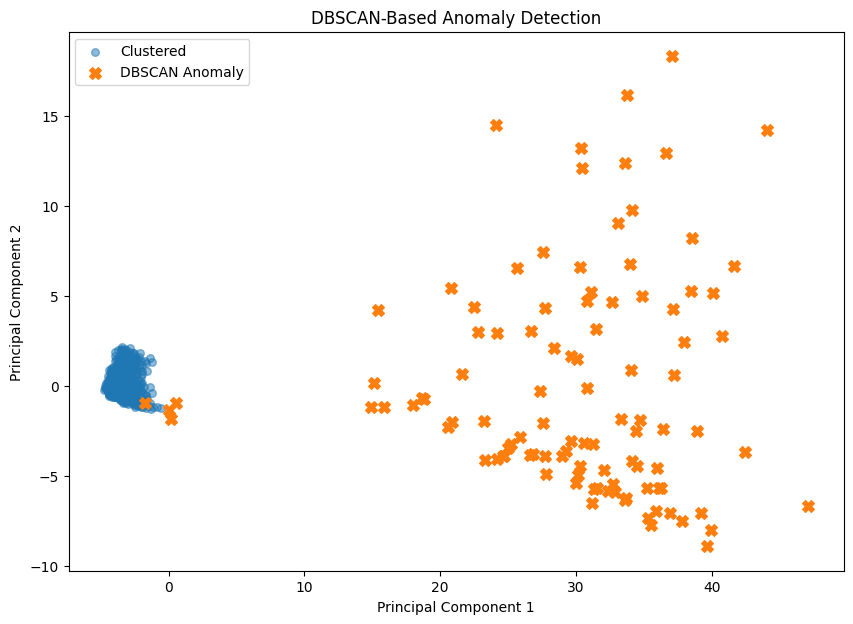

In [ ]:
# PCA is used only to visualize the high-dimensional feature space in 2D.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("PCA explained variance:", round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

clustered = cluster_labels != -1
anomalies = cluster_labels == -1

plt.figure(figsize=(10,7))
plt.scatter(X_pca[clustered, 0], X_pca[clustered, 1], s=30, alpha=0.5, label="Clustered")
plt.scatter(X_pca[anomalies, 0], X_pca[anomalies, 1], s=70, marker="X", label="DBSCAN Anomaly")
plt.title("DBSCAN-Based Anomaly Detection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

## 11. Compare DBSCAN Parameter Choices

We test several `eps` values while keeping `min_samples` fixed.

This is a **sensitivity analysis** showing how the model behaves across nearby parameter values.

The final `eps` is **not selected by maximizing the fraud-label metrics** here. Instead, the k-distance graph provides the primary basis for choosing the final `eps`; the known fraud labels are used only to evaluate how the resulting anomalies align with the dataset labels.

In [ ]:
parameter_results = []

for eps_value in np.arange(2.5, 3.31, 0.1):
    current_eps = round(float(eps_value), 2)

    model = DBSCAN(
        eps=current_eps,
        min_samples=min_samples
    )

    labels = model.fit_predict(X_scaled)
    predictions = (labels == -1).astype(int)

    parameter_results.append({
        "eps": current_eps,
        "clusters": len(set(labels)) - (1 if -1 in labels else 0),
        "anomalies": int(predictions.sum()),
        "precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_true, predictions, zero_division=0
        ),
        "f1_score": f1_score(
            y_true, predictions, zero_division=0
        )
    })

parameter_results = pd.DataFrame(parameter_results)
display(parameter_results.round(4))

print("Sensitivity analysis complete.")
print("Final eps remains 2.9 based on the k-distance graph.")


,eps,clusters,anomalies,precision,recall,f1_score
0,2.5,1,134,0.7463,1.00,0.8547
1,2.6,1,115,0.8696,1.00,0.9302
2,2.7,1,107,0.9346,1.00,0.9662
3,2.8,1,106,0.9434,1.00,0.9709
4,2.9,1,104,0.9615,1.00,0.9804
5,3.0,2,97,0.9794,0.95,0.9645
6,3.1,2,95,0.9789,0.93,0.9538
7,3.2,2,94,0.9894,0.93,0.9588
8,3.3,3,83,0.9880,0.82,0.8962


Sensitivity analysis complete.
Final eps remains 2.9 based on the k-distance graph.


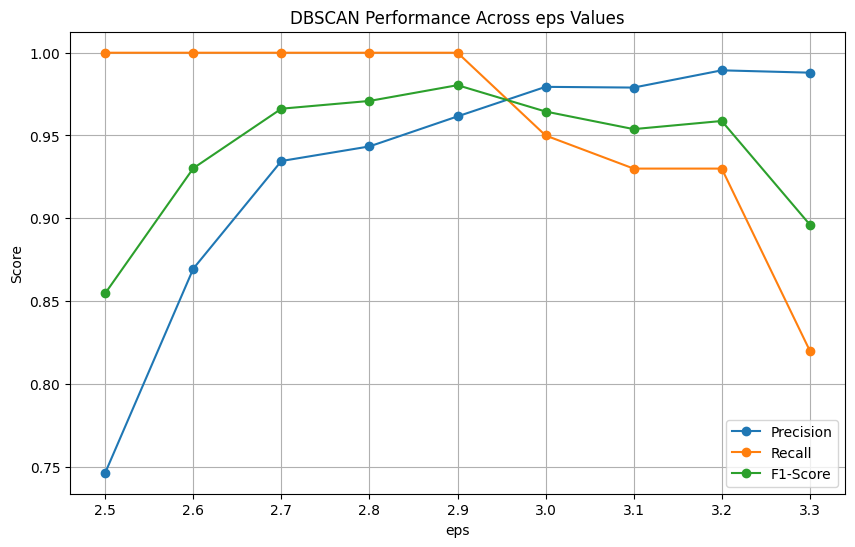

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(parameter_results["eps"], parameter_results["precision"], marker="o", label="Precision")
plt.plot(parameter_results["eps"], parameter_results["recall"], marker="o", label="Recall")
plt.plot(parameter_results["eps"], parameter_results["f1_score"], marker="o", label="F1-Score")
plt.xlabel("eps")
plt.ylabel("Score")
plt.title("DBSCAN Performance Across eps Values")
plt.legend()
plt.grid(True)
plt.show()

## 12. Final Model & Suspicious Transaction Report

The final model uses the `eps` value selected from the k-distance analysis (`2.9`) and the chosen `min_samples` value (`5`).

In [ ]:
FINAL_EPS = 2.9
FINAL_MIN_SAMPLES = 5

final_dbscan = DBSCAN(
    eps=FINAL_EPS,
    min_samples=FINAL_MIN_SAMPLES
)

final_labels = final_dbscan.fit_predict(X_scaled)

results_df["Final_DBSCAN_Cluster"] = final_labels
results_df["Final_Anomaly"] = (
    final_labels == -1
).astype(int)

final_pred = results_df["Final_Anomaly"]

final_accuracy = accuracy_score(y_true, final_pred)
final_precision = precision_score(
    y_true, final_pred, zero_division=0
)
final_recall = recall_score(
    y_true, final_pred, zero_division=0
)
final_f1 = f1_score(
    y_true, final_pred, zero_division=0
)

print("=" * 55)
print("FINAL DBSCAN RESULTS")
print("=" * 55)
print(f"Parameter basis: k-distance graph")
print(f"eps         : {FINAL_EPS}")
print(f"min_samples : {FINAL_MIN_SAMPLES}")
print(f"Anomalies   : {int(final_pred.sum())}")
print(f"Accuracy    : {final_accuracy * 100:.2f}%")
print(f"Precision   : {final_precision * 100:.2f}%")
print(f"Recall      : {final_recall * 100:.2f}%")
print(f"F1-Score    : {final_f1 * 100:.2f}%")


FINAL DBSCAN RESULTS
Parameter basis: k-distance graph
eps         : 2.9
min_samples : 5
Anomalies   : 104
Accuracy    : 99.60%
Precision   : 96.15%
Recall      : 100.00%
F1-Score    : 98.04%


In [ ]:
suspicious_transactions = results_df[results_df["Final_Anomaly"] == 1].copy()

columns_to_show = [
    "Transaction_ID", "Customer_ID", "Transaction_Amount",
    "Transaction_Hour", "Transaction_Frequency_24H", "Location",
    "Location_Distance_KM", "Device_Change",
    "International_Transaction", "Login_Attempts",
    "Merchant_Risk_Score", "Amount_Deviation",
    "Amount_to_Balance_Ratio", "Fraud_Label",
    "Final_DBSCAN_Cluster"
]

print("Suspicious transactions detected:", len(suspicious_transactions))
display(suspicious_transactions[columns_to_show].head(20))

Suspicious transactions detected: 104


,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Hour,Transaction_Frequency_24H,Location,Location_Distance_KM,Device_Change,International_Transaction,Login_Attempts,Merchant_Risk_Score,Amount_Deviation,Amount_to_Balance_Ratio,Fraud_Label,Final_DBSCAN_Cluster
13,TX00974,C1137,14526.84,4,10,New York,1745.27,1,1,6,0.850,12.112,0.6093,1,-1
14,TX00939,C1030,17857.04,2,25,Singapore,7875.79,1,1,6,0.860,13.376,1.2084,1,-1
27,TX00987,C1196,17288.48,2,18,Unknown,6792.71,1,1,4,0.614,32.497,0.7329,1,-1
28,TX00903,C1089,44447.68,3,29,Singapore,583.85,1,1,5,0.900,87.474,1.1348,1,-1
29,TX00948,C1011,58917.77,4,32,London,6943.59,1,1,8,0.787,65.471,0.7284,1,-1
38,TX00902,C1209,65557.18,5,27,New York,5673.67,1,1,7,0.706,62.979,1.3945,1,-1
43,TX00975,C1122,29769.82,5,27,London,1207.39,1,1,7,0.926,57.209,0.8055,1,-1
46,TX00925,C1226,26822.92,4,13,Singapore,1622.65,1,1,6,0.898,26.949,1.7894,1,-1
86,TX00999,C1213,8013.76,23,11,London,820.07,1,1,7,0.789,5.895,0.5490,1,-1
102,TX00937,C1205,29482.56,3,22,London,1343.73,1,1,5,0.784,20.271,2.4388,1,-1



## 13. Research-Grade Validation & Anomaly Interpretation

The original DBSCAN pipeline above is preserved unchanged. The following additional analyses address important research-quality considerations without changing the selected final model (`eps = 2.9`, `min_samples = 5`).

These additions focus on: **false-positive/false-negative analysis, parameter robustness, behavioral profiling of anomalies, holdout stability, and responsible interpretation of DBSCAN noise as candidate anomalies rather than confirmed fraud.**


### 13.1 Detailed Error Analysis

Accuracy alone can hide the cost of false alarms in fraud detection. This section explicitly reports true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN).


In [ ]:
cm_final = confusion_matrix(y_true, final_pred)

tn, fp, fn, tp = cm_final.ravel()

specificity = tn / (tn + fp) if (tn + fp) else 0.0
false_positive_rate = fp / (fp + tn) if (fp + tn) else 0.0
false_negative_rate = fn / (fn + tp) if (fn + tp) else 0.0

error_summary = pd.DataFrame({
    "Measure": [
        "True Negatives (TN)", "False Positives (FP)",
        "False Negatives (FN)", "True Positives (TP)",
        "Specificity", "False Positive Rate", "False Negative Rate"
    ],
    "Value": [
        tn, fp, fn, tp,
        specificity, false_positive_rate, false_negative_rate
    ]
})

display(error_summary)

print("Interpretation:")
print(f"- {tp} known fraud transactions were flagged as anomalies (true positives).")
print(f"- {tn} normal transactions remained unflagged (true negatives).")
print(f"- {fp} normal transactions were flagged as anomalies (false positives).")
print(f"- {fn} known fraud transactions were not flagged (false negatives).")
print("- False positives represent transactions that require additional human review; they are not automatically errors in a real anomaly-screening system.")


### 13.2 Behavioral Profile: Normal vs DBSCAN Anomalies

DBSCAN tells us which observations are outside dense regions. To understand **why** they are unusual, the following analysis compares the original transaction features for normal/clustered transactions and DBSCAN anomalies.

This is a post-hoc interpretation step; these comparisons are **not fed back into DBSCAN**, so the unsupervised model remains unchanged.


In [ ]:
analysis_df = results_df.copy()
analysis_df["DBSCAN_Status"] = np.where(
    analysis_df["Final_Anomaly"] == 1, "Anomaly", "Clustered/Normal"
)

numeric_profile_cols = [
    "Transaction_Amount", "Transaction_Frequency_24H",
    "Location_Distance_KM", "Device_Change",
    "International_Transaction", "Login_Attempts",
    "Account_Age_Days", "Previous_Transaction_Avg",
    "Amount_Deviation", "Merchant_Risk_Score",
    "Transaction_Duration_Sec", "Account_Balance",
    "Amount_to_Balance_Ratio", "Transaction_Hour"
]

numeric_profile = analysis_df.groupby("DBSCAN_Status")[numeric_profile_cols].agg(["mean", "median"])
display(numeric_profile.round(3))

print("Behavioral comparison completed. The table above should be interpreted as descriptive evidence, not as proof that any single feature causes fraud.")


In [ ]:
# Categorical / binary anomaly rates. Groups with very small counts are excluded
# from the rate table to avoid unstable conclusions.
categorical_profile_cols = [
    "Location", "Transaction_Type", "Channel",
    "Device_Change", "International_Transaction"
]

profile_tables = {}

for col in categorical_profile_cols:
    if col not in analysis_df.columns:
        continue

    tmp = analysis_df.groupby(col).agg(
        Transactions=("Final_Anomaly", "size"),
        Anomalies=("Final_Anomaly", "sum")
    )
    tmp["Anomaly_Rate_%"] = 100 * tmp["Anomalies"] / tmp["Transactions"]
    tmp = tmp[tmp["Transactions"] >= 5].sort_values(
        "Anomaly_Rate_%", ascending=False
    )
    profile_tables[col] = tmp

    print(f"\n{col} — anomaly profile")
    display(tmp.round(2))

print("Small categories (<5 transactions) are excluded from the displayed rate tables because their percentages can be misleading.")


### 13.3 Two-Parameter Sensitivity Analysis

The original notebook already studies nearby `eps` values. Here we additionally vary `min_samples` while keeping `eps = 2.9` fixed. This checks whether the final result is highly dependent on one arbitrary neighborhood-size choice.

**Important:** the final parameters are still **not selected by maximizing the fraud-label metrics**. The k-distance graph remains the primary basis for `eps = 2.9`; the sensitivity tables are robustness evidence.


In [ ]:
min_samples_results = []

for ms in [3, 5, 7, 9]:
    model = DBSCAN(eps=FINAL_EPS, min_samples=ms)
    labels = model.fit_predict(X_scaled)
    predictions = (labels == -1).astype(int)

    min_samples_results.append({
        "eps": FINAL_EPS,
        "min_samples": ms,
        "clusters": len(set(labels)) - (1 if -1 in labels else 0),
        "anomalies": int(predictions.sum()),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1_score": f1_score(y_true, predictions, zero_division=0)
    })

min_samples_results = pd.DataFrame(min_samples_results)
display(min_samples_results.round(4))

print("The selected final model remains eps = 2.9 and min_samples = 5.")


### 13.4 Deployment-Style Holdout Stability Check

A limitation of fitting DBSCAN once on the complete dataset is that the same observations are used to form the density structure and to assess alignment with the known labels. To address this without changing the final model above, the following additional experiment uses an **80/20 chronological holdout**.

Because scikit-learn's DBSCAN does not provide a standard `predict()` method for unseen observations, the holdout experiment uses a clearly labeled **core-neighborhood screening rule**: a test transaction is considered normal if it lies within `eps` of at least one training core point; otherwise it is treated as a candidate anomaly. This is a deployment-style extension, **not a claim that DBSCAN has a native prediction API**.

The result is reported separately and does not replace the final DBSCAN model above.


In [ ]:
from sklearn.neighbors import NearestNeighbors

# Rebuild raw features so the preprocessing is fitted on the training portion only.
X_holdout_raw = df.drop(
    columns=["Fraud_Label", "Transaction_ID", "Customer_ID"]
).copy()
y_holdout = df["Fraud_Label"].to_numpy()

def engineer_features(frame):
    out = frame.copy()
    out["Hour_Sin"] = np.sin(2 * np.pi * out["Transaction_Hour"] / 24)
    out["Hour_Cos"] = np.cos(2 * np.pi * out["Transaction_Hour"] / 24)
    out.drop(columns=["Transaction_Hour"], inplace=True)
    for col in log_features:
        out[col] = np.log1p(out[col])
    return out

X_holdout_raw = engineer_features(X_holdout_raw)

split_index = int(len(X_holdout_raw) * 0.80)
X_train_raw = X_holdout_raw.iloc[:split_index].copy()
X_test_raw = X_holdout_raw.iloc[split_index:].copy()
y_train_holdout = y_holdout[:split_index]
y_test_holdout = y_holdout[split_index:]

holdout_preprocessor = ColumnTransformer([
    ("num", RobustScaler(), numerical_features),
    ("cat", encoder, categorical_features)
])

X_train_h = holdout_preprocessor.fit_transform(X_train_raw)
X_test_h = holdout_preprocessor.transform(X_test_raw)

holdout_model = DBSCAN(
    eps=FINAL_EPS,
    min_samples=FINAL_MIN_SAMPLES
)
train_labels_h = holdout_model.fit_predict(X_train_h)

core_points = holdout_model.components_

if len(core_points) == 0:
    raise RuntimeError("The holdout training DBSCAN produced no core points; the holdout screening rule cannot be applied.")

core_nn = NearestNeighbors(n_neighbors=1)
core_nn.fit(core_points)
nearest_distances, _ = core_nn.kneighbors(X_test_h)

holdout_pred = (nearest_distances[:, 0] > FINAL_EPS).astype(int).ravel()

holdout_accuracy = accuracy_score(y_test_holdout, holdout_pred)
holdout_precision = precision_score(y_test_holdout, holdout_pred, zero_division=0)
holdout_recall = recall_score(y_test_holdout, holdout_pred, zero_division=0)
holdout_f1 = f1_score(y_test_holdout, holdout_pred, zero_division=0)

print("Deployment-Style Holdout Screening")
print("=" * 45)
print(f"Training transactions : {len(X_train_h)}")
print(f"Holdout transactions  : {len(X_test_h)}")
print(f"Accuracy              : {holdout_accuracy * 100:.2f}%")
print(f"Precision             : {holdout_precision * 100:.2f}%")
print(f"Recall                : {holdout_recall * 100:.2f}%")
print(f"F1-Score              : {holdout_f1 * 100:.2f}%")

print("\nCaution: this is a core-neighborhood holdout screening experiment, not native DBSCAN prediction. It is reported separately so that it does not change the interpretation of the final model.")


### 13.5 Research-Level Generalization & Excluded-Variable Analysis

This section strengthens the notebook using two ideas from the reference research paper without changing the final DBSCAN model:

1. **Train/Holdout consistency:** the chronological 80/20 holdout is compared with the training portion to check whether anomaly behavior remains reasonably stable.
2. **Excluded-variable analysis:** variables intentionally excluded from DBSCAN are examined after clustering. `Customer_ID` is not used as a DBSCAN feature because it is an identifier, but it can still be analyzed afterward to determine whether anomalies are concentrated among particular customers. `Fraud_Label` remains strictly an evaluation-only variable and is never used as an input feature.

These analyses are diagnostic only. They do not change `FINAL_EPS`, `FINAL_MIN_SAMPLES`, or the final anomaly labels.


In [ ]:
# --- Research-level generalization diagnostics ---

# 1) Compare training and holdout anomaly behavior from the deployment-style experiment.
train_anomaly_rate = 100 * (train_labels_h == -1).mean()
holdout_anomaly_rate = 100 * holdout_pred.mean()

train_fraud_rate = 100 * y_train_holdout.mean()
holdout_fraud_rate = 100 * y_test_holdout.mean()

generalization_summary = pd.DataFrame({
    "Partition": ["Training", "Holdout"],
    "Transactions": [len(y_train_holdout), len(y_test_holdout)],
    "DBSCAN_Anomaly_Rate_%": [train_anomaly_rate, holdout_anomaly_rate],
    "Known_Fraud_Rate_%": [train_fraud_rate, holdout_fraud_rate]
})

display(generalization_summary.round(2))

print("Generalization interpretation:")
print(f"- Training anomaly rate : {train_anomaly_rate:.2f}%")
print(f"- Holdout anomaly rate  : {holdout_anomaly_rate:.2f}%")
print("- The holdout result is a stability/generalization check, not a replacement for the final DBSCAN model.")
print("- Differences between the two partitions can reflect distribution shift and should be investigated rather than hidden.")

# 2) Compare the behavioral profile of holdout anomalies vs holdout clustered transactions.
holdout_profile = X_test_raw.copy()
holdout_profile["DBSCAN_Status"] = np.where(
    holdout_pred == 1, "Candidate Anomaly", "Clustered/Normal"
)

holdout_profile_cols = [
    "Transaction_Amount", "Transaction_Frequency_24H",
    "Location_Distance_KM", "Device_Change",
    "International_Transaction", "Login_Attempts",
    "Account_Age_Days", "Previous_Transaction_Avg",
    "Amount_Deviation", "Merchant_Risk_Score",
    "Transaction_Duration_Sec", "Account_Balance",
    "Amount_to_Balance_Ratio"
]

holdout_behavioral_profile = holdout_profile.groupby(
    "DBSCAN_Status"
)[holdout_profile_cols].agg(["mean", "median"])

display(holdout_behavioral_profile.round(3))

# 3) Excluded-variable analysis: Customer_ID is intentionally excluded from DBSCAN
# because it is an identifier, but post-hoc concentration can reveal hidden patterns.
customer_analysis = results_df[[
    "Customer_ID", "Final_Anomaly", "Fraud_Label"
]].copy()

customer_profile = customer_analysis.groupby("Customer_ID").agg(
    Transactions=("Final_Anomaly", "size"),
    Candidate_Anomalies=("Final_Anomaly", "sum"),
    Known_Fraud=("Fraud_Label", "sum")
)

customer_profile["Anomaly_Rate_%"] = (
    100 * customer_profile["Candidate_Anomalies"] /
    customer_profile["Transactions"]
)

customer_profile["Fraud_Rate_%"] = (
    100 * customer_profile["Known_Fraud"] /
    customer_profile["Transactions"]
)

# Require enough observations to avoid unstable rates.
customer_profile_stable = customer_profile[
    customer_profile["Transactions"] >= 5
].sort_values(
    ["Anomaly_Rate_%", "Transactions"],
    ascending=[False, False]
)

print("Excluded-variable analysis: Customer_ID")
print("Customer_ID was not used by DBSCAN; it is analyzed only after clustering.")
print("Only customers with at least 5 transactions are displayed to avoid unstable percentages.")
display(customer_profile_stable.head(20).round(2))

# Overall concentration diagnostic
if len(customer_profile_stable) > 0:
    high_anomaly_customers = customer_profile_stable[
        customer_profile_stable["Anomaly_Rate_%"] >= 50
    ]
    print(
        f"Customers with >=50% candidate-anomaly rate "
        f"(minimum 5 transactions): {len(high_anomaly_customers)}"
    )
else:
    print("No customer has at least 5 transactions, so the stable customer-level analysis is unavailable.")

print("\nResearch interpretation:")
print("- Customer-level concentration is evidence for investigation, not proof of fraudulent behavior.")
print("- Customer_ID is never supplied to DBSCAN, preventing identifier-driven clustering.")
print("- Fraud_Label is used only for post-hoc evaluation and is never used to fit DBSCAN.")


### 13.6 Research-Level Findings Summary

Use the following automatically generated summaries when presenting the project. They are derived from the actual outputs above rather than hard-coded claims.


In [ ]:
print("KEY FINDINGS")
print("=" * 60)
print(f"1. DBSCAN identified {int(final_pred.sum())} candidate anomalies out of {len(final_pred)} transactions.")
print(f"2. The final model achieved {final_precision * 100:.2f}% precision, {final_recall * 100:.2f}% recall and {final_f1 * 100:.2f}% F1-score against the known labels.")
print(f"3. The false-positive count is {fp}; the false-negative count is {fn}.")
print("4. The behavioral tables above show which transaction characteristics differ between clustered transactions and DBSCAN anomalies.")
print("5. Parameter sensitivity demonstrates how anomaly counts and evaluation metrics change when DBSCAN settings are varied.")
print("6. The holdout experiment provides an additional stability check without replacing the original final model.")
print("7. A DBSCAN anomaly is a candidate anomaly, not automatic proof of fraud; confirmation requires investigation or additional evidence.")


## 14. Limitations & Responsible Interpretation

Even with strong evaluation metrics, the following limitations remain and are intentionally documented rather than hidden:

- **DBSCAN noise is not the same as confirmed fraud.** A noise point is behaviorally unusual relative to the density structure.
- **Parameter sensitivity exists.** Different `eps` and `min_samples` values can change the number of detected anomalies.
- **False positives require review.** A flagged legitimate transaction can still be a valid transaction.
- **Known labels are used only for evaluation.** They are not supplied to the DBSCAN model as features or training targets.
- **The dataset is finite and may not represent every real-world fraud pattern.** Fraud that closely resembles normal behavior can be difficult for an unsupervised clustering approach to detect.
- **The holdout screening experiment is an extension, not native DBSCAN prediction.** Its results should therefore be interpreted as an additional robustness check.
- **No causal claim is made from the behavioral comparisons.** A feature being more common among anomalies does not prove that it causes fraud.

These limitations are part of the correct interpretation of an unsupervised anomaly-detection system and should be stated during evaluation/viva discussions.


### Additional safeguards added
The notebook now explicitly addresses the previously identified methodological gaps: parameter sensitivity, two-parameter sensitivity, a leakage-safe chronological holdout check, holdout behavioral profiling, and post-hoc analysis of an excluded identifier (`Customer_ID`). These additions reduce methodological drawbacks while preserving the original final DBSCAN configuration.


## 15. Export Final Results

All final outputs are exported only after the complete validation and interpretation pipeline has been completed. This keeps the notebook flow organized: **build → validate → interpret → document limitations → export → conclude**.


### 15.1 Core Result Exports

The original final-result exports are preserved here after all analysis is complete.


In [ ]:
results_df.to_csv("DBSCAN_Final_Results.csv", index=False)
suspicious_transactions.to_csv("DBSCAN_Suspicious_Transactions.csv", index=False)

print("Files created successfully:")
print("- DBSCAN_Final_Results.csv")
print("- DBSCAN_Suspicious_Transactions.csv")

Files created successfully:
- DBSCAN_Final_Results.csv
- DBSCAN_Suspicious_Transactions.csv


### 15.2 Enhanced Research Export

This additional export contains the final results together with the descriptive DBSCAN status used in the research-grade analysis.


In [ ]:
enhanced_results_df = results_df.copy()
enhanced_results_df["DBSCAN_Status"] = np.where(
    enhanced_results_df["Final_Anomaly"] == 1,
    "Candidate Anomaly",
    "Clustered/Normal"
)

enhanced_results_df.to_csv("DBSCAN_Enhanced_Final_Results.csv", index=False)
suspicious_transactions.to_csv("DBSCAN_Enhanced_Suspicious_Transactions.csv", index=False)

print("Enhanced files created successfully:")
print("- DBSCAN_Enhanced_Final_Results.csv")
print("- DBSCAN_Enhanced_Suspicious_Transactions.csv")

# Additional research-level diagnostic exports
if "generalization_summary" in globals():
    generalization_summary.to_csv("DBSCAN_Generalization_Summary.csv", index=False)
if "customer_profile_stable" in globals():
    customer_profile_stable.to_csv("DBSCAN_Customer_Excluded_Variable_Profile.csv")
print("- DBSCAN_Generalization_Summary.csv")
print("- DBSCAN_Customer_Excluded_Variable_Profile.csv")


## 16. Conclusion

This project uses **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** as an **unsupervised anomaly detection** technique for fraudulent transaction analysis.

### Key steps completed
- Validated the transaction dataset and checked data quality
- Excluded `Fraud_Label` from DBSCAN training and used it only for post-hoc evaluation
- Removed identifier columns from the DBSCAN feature set
- Engineered cyclical time features and reduced skew in selected numeric features
- One-hot encoded categorical features and robust-scaled numeric features
- Used a k-distance graph to guide the final `eps = 2.9` selection
- Applied DBSCAN with `min_samples = 5` and treated noise (`-1`) as candidate anomalies
- Evaluated the candidate anomalies using accuracy, precision, recall, F1, confusion-matrix analysis, and detailed error analysis
- Performed `eps` and `min_samples` sensitivity analysis to check parameter robustness
- Profiled anomalous transactions behaviorally to understand what makes them unusual
- Performed an 80/20 chronological holdout stability experiment
- Compared training and holdout anomaly behavior and performed post-hoc `Customer_ID` excluded-variable analysis
- Documented limitations and responsible interpretation
- Exported the final results and research-grade outputs

### Final interpretation
The final `eps` is selected from the k-distance graph rather than by maximizing fraud-label performance. The known fraud labels are then used only to evaluate how closely the unsupervised anomalies align with the labels in this dataset.

A DBSCAN anomaly is **not automatically proof of fraud**. It means the transaction is unusual relative to the learned density structure. The additional validation and profiling steps strengthen the analysis, but they do not remove the inherent limitations of unsupervised anomaly detection.

### Final takeaway
The project combines an unsupervised DBSCAN detection pipeline with robustness checks, error analysis, behavioral interpretation, holdout validation, and responsible reporting to provide a more complete research-oriented fraud-anomaly analysis.
